# 07 · Generación de imágenes de gatos desde checkpoint (`cats_vp.yaml`)

Este notebook permite **generar muestras de imágenes (gatos)** a partir de un modelo de score
`ScoreUNet` (Fase 2) entrenado con la configuración **`config/cats_vp.yaml`** (o cualquier checkpoint compatible).

### Objetivos y estructura:
1. **Configuración y Checkpoint**: Cargar la receta desde `config/cats_vp.yaml` e inspeccionar la metadata del checkpoint.
2. **Generación desde ruido (Prueba 3 - Notebook 06)**: Partir de $x_T \sim \mathcal{N}(0, I)$ e integrar el proceso reverso con **Predictor-Corrector (`pc`)**.
3. **Estudio de Samplers del Eje 2**: Comparar los 4 samplers del reverso (`euler`, `pf_ode`, `heun`, `pc`) manteniendo el **mismo score $s_\theta(x,t)$ y la misma semilla de ruido**.
4. **Visualización de Trayectorias**: Observar la evolución temporal del proceso reverso $x_t \to x_0$ a lo largo de la integración.
5. **Análisis de Overfitting (Vecinos Más Cercanos)**: Buscar las imágenes del dataset de entrenamiento con menor distancia MSE a las muestras generadas para determinar si el modelo memorizó o generalizó la distribución.

In [18]:
# --- Setup: bootstrap de sys.path + imports + helpers de visualización ---
import sys
import pathlib
import yaml

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.samplers import generate_from_checkpoint, available_samplers, make_sampler
from diffusion.training import load_checkpoint
from diffusion.sde import make_sde
from diffusion.models import make_model, EpsilonScoreWrapper
from diffusion.data_generation import infinite_batches

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})


def denorm(t):
    """(B,3,H,W) en [-1,1] -> (B,H,W,3) numpy en [0,1]."""
    x = (t.detach() * 0.5 + 0.5).clamp(0.0, 1.0)
    return x.permute(0, 2, 3, 1).cpu().numpy()


def show_grid(imgs, titles=None, suptitle=None, cols=4):
    """Muestra un lote de imágenes (B,3,H,W) o (B,H,W,3) en grilla."""
    arr = denorm(imgs) if torch.is_tensor(imgs) else imgs
    n = arr.shape[0]
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.8 * cols, 3.0 * rows))
    axes_flat = np.atleast_1d(axes).flat
    for i in range(rows * cols):
        if i < n:
            axes_flat[i].imshow(arr[i])
            axes_flat[i].axis("off")
            if titles is not None and i < len(titles):
                axes_flat[i].set_title(titles[i], fontsize=9)
        else:
            axes_flat[i].axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()


print("Paquete en:", _root)
print("PyTorch versión:", torch.__version__)
print("Samplers disponibles:", available_samplers())

# --- Presupuesto de computo: NFE, no pasos --------------------------------------
# Cada sampler gasta un numero DISTINTO de evaluaciones del score por paso (contado
# sobre el codigo de diffusion/samplers):
#   euler   -> 1                (_reverse_drift)
#   pf_ode  -> 1                (_pfode_drift)
#   heun    -> 2                (drift en t y en el estado predicho a t+dt)
#   pc      -> 1 + n_corrector  (predictor + cada correccion de Langevin)
# Darles el mismo `n_steps` NO es darles el mismo computo: heun y pc gastan el doble.
# Con la U-Net dominando el costo, el NFE es basicamente el tiempo de pared, asi que
# comparar samplers a `n_steps` igualado le regala 2x a dos de los cuatro.
import time

N_CORRECTOR = 1
NFE_POR_PASO = {"euler": 1, "pf_ode": 1, "heun": 2, "pc": 1 + N_CORRECTOR}


def pasos_para(nom_sampler, nfe):
    """Pasos de integracion que gastan `nfe` evaluaciones de score con este sampler."""
    if nom_sampler not in NFE_POR_PASO:
        raise KeyError(f"NFE/paso desconocido para '{nom_sampler}'; agregalo a NFE_POR_PASO")
    return max(1, nfe // NFE_POR_PASO[nom_sampler])


def kwargs_para(nom_sampler):
    """Kwargs propios del sampler. Solo `pc` los tiene, y `n_corrector` va explicito
    porque el conteo de NFE depende de el: si cambia el default, el conteo miente."""
    return {"n_corrector": N_CORRECTOR} if nom_sampler == "pc" else {}


print("NFE por paso:", NFE_POR_PASO)

Paquete en: /home/abravo/estocastico/diffusion-models
PyTorch versión: 2.12.0+cu130
Samplers disponibles: ['euler', 'heun', 'pc', 'pf_ode']


## 1. Localización del Checkpoint e Inspección de Metadata

Leemos `config/cats_vp.yaml` para obtener la ruta objetivo del checkpoint (`out.checkpoint`).
Si el checkpoint entrenado en GPU (`cats_vp.pt`) aún no está presente en la ruta local, usamos como respaldo el checkpoint `models/phase_2/cats_prueba_vp.pt` generado en la prueba de integración de Fase 2.

In [19]:
# --- Cargar configuración y verificar checkpoint ---
config_path = _root / "config" / "cats_vp-overfitting.yaml"

if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    target_ckpt = pathlib.Path(cfg["out"]["checkpoint"])
    print(f"Configuración cargada desde: {config_path}")
    print(f"Ruta objetivo del checkpoint (YAML): {target_ckpt}")
else:
    target_ckpt = pathlib.Path("/mnt/data/abravo/diffusion-models/phase_2/cats_vp.pt")
    print(f"No se encontró {config_path}, usando ruta por defecto: {target_ckpt}")

# Búsqueda de candidato de checkpoint existente
candidate_paths = [
    target_ckpt,
    _root / "models" / "phase_2" / "cats_vp.pt",
]

CKPT_PATH = None
for cand in candidate_paths:
    if cand.exists():
        CKPT_PATH = cand
        break

if CKPT_PATH is None:
    raise FileNotFoundError(
        f"No se encontró ningún checkpoint en las rutas probadas: {[str(p) for p in candidate_paths]}"
    )

print(f"\nUsing checkpoint: {CKPT_PATH}")

# Cargar metadata sin instanciar pesos
state_dict, meta = load_checkpoint(CKPT_PATH, map_location="cpu")

print("\n--- Metadata del Checkpoint ---")
print("SDE          :", meta.get("sde_name"), f"(data_dim={meta.get('data_dim')})")
model_recipe = meta.get("model", {})
print("Modelo       :", model_recipe.get("name"), f"kwargs={model_recipe.get('kwargs')}")
print("Parametrización:", model_recipe.get("score_parametrization", "score directo"))

if "history" in meta:
    hist = meta["history"]
    print(f"Historial    : {len(hist)} registros de loss (Loss inicial: {hist[0]:.4f} -> final: {hist[-1]:.4f})")

Configuración cargada desde: /home/abravo/estocastico/diffusion-models/config/cats_vp-overfitting.yaml
Ruta objetivo del checkpoint (YAML): /mnt/data/abravo/diffusion-models/phase_2-overfitting/cats_vp.pt

Using checkpoint: /mnt/data/abravo/diffusion-models/phase_2-overfitting/cats_vp.pt

--- Metadata del Checkpoint ---
SDE          : vp (data_dim=(3, 64, 64))
Modelo       : unet kwargs={'in_channels': 3, 'image_size': 64, 'base_channels': 128, 'channel_mults': [1, 2, 2, 2], 'num_res_blocks': 2, 'embed_dim': 256, 'time_embed_dim': 512, 'attn_resolutions': [16, 8], 'groups': 32, 'time_scale': 1000.0}
Parametrización: epsilon
Historial    : 120000 registros de loss (Loss inicial: 1.0418 -> final: 0.0202)


## 2. Generación desde ruido con Predictor-Corrector (`pc`)

Invocamos `generate_from_checkpoint` para partir de $x_T \sim \mathcal{N}(0, I)$ e integrar el reverso con el sampler Predictor-Corrector (`pc`).
Las correcciones de Langevin del predictor-corrector ayudan a mantener la trayectoria cerca de la variedad de datos.

Generando 4 muestras con sampler 'pc' (1000 pasos)...
Tensor generado: shape=(4, 3, 64, 64), dtype=torch.float32
Rango de valores: min=-1.027, max=1.039
¿Valores finitos (sin NaNs/Infs)?: True


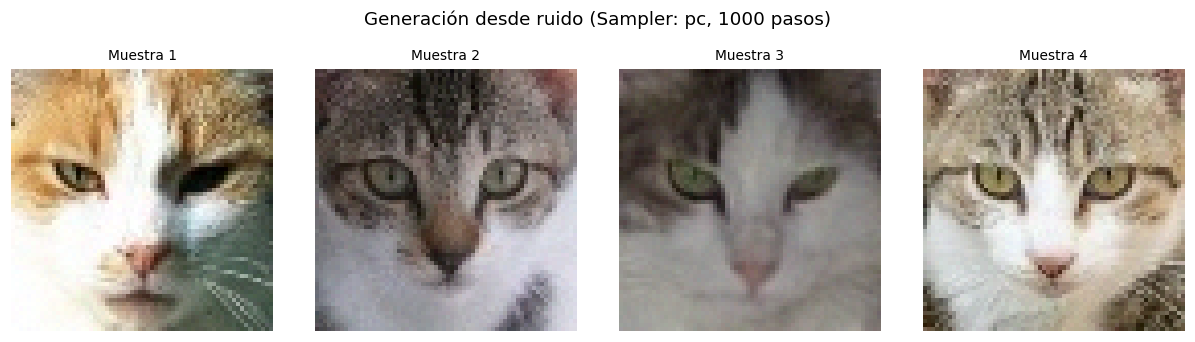

In [21]:
# --- Generación desde ruido usando Predictor-Corrector (en GPU) ---
N_SAMPLES = 4
SAMPLER_NAME = "pc"
NFE = 2000                                   # presupuesto en evaluaciones de la U-Net
N_STEPS = pasos_para(SAMPLER_NAME, NFE)      # 'pc' gasta 2 por paso -> 1000 pasos

print(f"Generando {N_SAMPLES} muestras con '{SAMPLER_NAME}': "
      f"{N_STEPS} pasos x {NFE_POR_PASO[SAMPLER_NAME]} = {NFE} NFE")

samples_pc = generate_from_checkpoint(
    CKPT_PATH,
    sampler_name=SAMPLER_NAME,
    n_samples=N_SAMPLES,
    n_steps=N_STEPS,
    seed=SEED,
    device="cuda",     # <-- corre en GPU (mueve la red + samplea en cuda). map_location NO alcanzaba.
    **kwargs_para(SAMPLER_NAME),   # n_corrector explícito: el conteo de NFE depende de él
).cpu()                # <-- a CPU para graficar/analizar sin líos de device

print(f"Tensor generado: shape={tuple(samples_pc.shape)}, dtype={samples_pc.dtype}")
print(f"Rango de valores: min={float(samples_pc.min()):.3f}, max={float(samples_pc.max()):.3f}")
print("¿Valores finitos (sin NaNs/Infs)?:", bool(torch.isfinite(samples_pc).all()))

show_grid(
    samples_pc,
    titles=[f"Muestra {i+1}" for i in range(N_SAMPLES)],
    suptitle=f"Generación desde ruido ({SAMPLER_NAME}, {N_STEPS} pasos = {NFE} NFE)",
    cols=4
)

## 3. Estudio de Ablación de Samplers (Eje 2)

Manteniendo **fija la red de score $s_\theta(x,t)$** y la **misma semilla de ruido inicial $x_T$**, comparamos el comportamiento de los distintos samplers del reverso:
1. **`euler`**: Euler–Maruyama (estocástico).
2. **`pf_ode`**: Probability-Flow ODE (Euler determinístico).
3. **`heun`**: Predictor-Corrector de 2º orden para ODE (EDM).
4. **`pc`**: Predictor-Corrector (SDE + corrección Langevin).

### El presupuesto se iguala en NFE, no en pasos

Los cuatro samplers integran el mismo reverso, pero **no cuestan lo mismo por paso**. Contando las llamadas a `score_fn`
—o sea, los *forward* de la U-Net, que son el 99% del costo— en el código de `diffusion/samplers`:

| sampler | NFE / paso | por qué | pasos con 2000 NFE |
|---|---|---|---|
| `euler` | 1 | un solo `_reverse_drift` | 2000 |
| `pf_ode` | 1 | un solo `_pfode_drift` | 2000 |
| `heun` | 2 | drift en $t$ **y** en el estado predicho a $t+dt$ | 1000 |
| `pc` | 1 + `n_corrector` | predictor + cada corrección de Langevin | 1000 |

Darles el mismo `n_steps` es lo natural y es **injusto**: con `n_steps=1000` para los cuatro, `heun` y `pc` gastan 2000
evaluaciones contra las 1000 de `euler` y `pf_ode`. El doble de cómputo. Y el argumento entero de Heun es *mejor calidad
por NFE*, así que medirlo con el doble de presupuesto no prueba nada.

La celda de abajo fija el **NFE** y deriva los pasos de cada uno. Imprime el tiempo de pared por sampler: si el
presupuesto quedó bien igualado, los cuatro tardan parecido.

Generando muestras con sampler 'euler' (1000 pasos)...


Generando muestras con sampler 'pf_ode' (1000 pasos)...
Generando muestras con sampler 'heun' (1000 pasos)...
Generando muestras con sampler 'pc' (1000 pasos)...


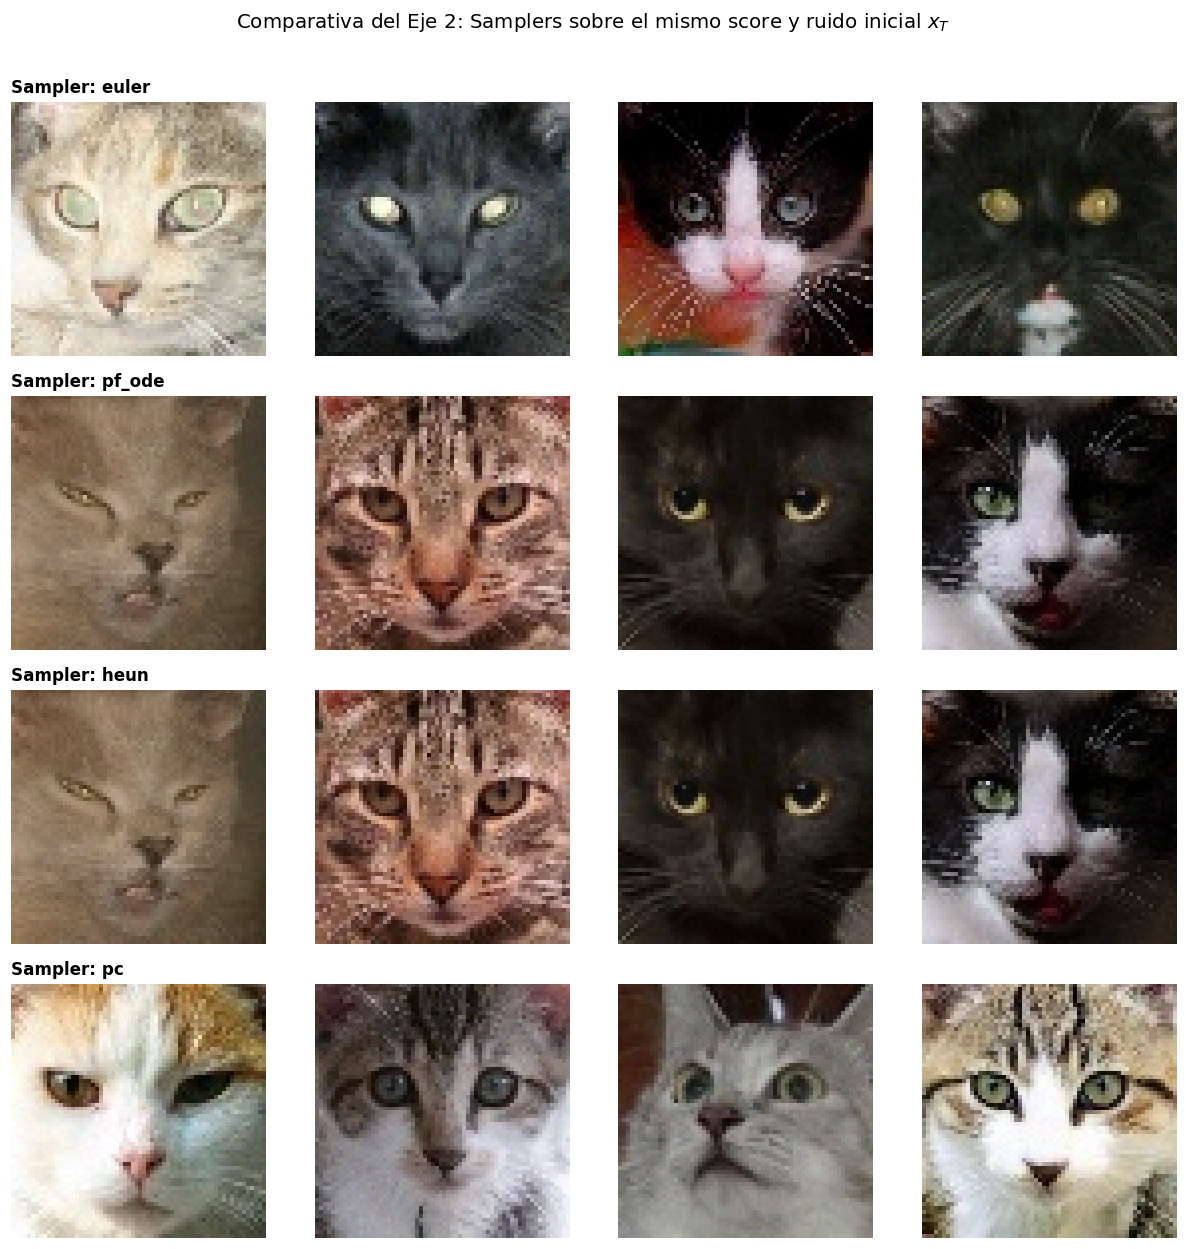

In [ ]:
# --- Comparación de los 4 samplers a PRESUPUESTO DE NFE IGUALADO (en GPU) ---
# Esta celda antes le daba el mismo `n_steps` a los cuatro, que es lo natural y es INJUSTO:
# heun y pc gastan 2 evaluaciones de la U-Net por paso, asi que con n_steps=1000 corrian a
# 2000 NFE contra los 1000 de euler y pf_ode -- literalmente el doble de computo. Ahora se
# fija el NFE y cada sampler recibe los pasos que le entran en ese presupuesto.
samplers_to_compare = ["euler", "pf_ode", "heun", "pc"]
num_samples_cmp = 4
NFE_CMP = 2000

print(f"presupuesto igualado: {NFE_CMP} NFE por sampler\n")
print(f"{'sampler':8s} {'NFE/paso':>9s} {'pasos':>7s} {'NFE':>6s} {'tiempo':>8s} "
      f"{'rango':>16s} {'finito':>7s}")

sampler_results = {}
pasos_usados = {}

for s_name in samplers_to_compare:
    pasos = pasos_para(s_name, NFE_CMP)
    pasos_usados[s_name] = pasos
    t0 = time.time()
    samples = generate_from_checkpoint(
        CKPT_PATH,
        sampler_name=s_name,
        n_samples=num_samples_cmp,
        n_steps=pasos,
        seed=SEED,          # misma semilla -> mismo x_T inicial
        device="cuda",      # <-- en GPU
        **kwargs_para(s_name),
    ).cpu()
    transcurrido = time.time() - t0
    sampler_results[s_name] = samples
    rango = f"({float(samples.min()):.2f}, {float(samples.max()):.2f})"
    print(f"{s_name:8s} {NFE_POR_PASO[s_name]:9d} {pasos:7d} "
          f"{pasos * NFE_POR_PASO[s_name]:6d} {transcurrido:7.1f}s {rango:>16s} "
          f"{str(bool(torch.isfinite(samples).all())):>7s}")

print()
print("El tiempo de pared debería quedar parecido entre los cuatro: es la comprobación")
print("empírica de que el presupuesto está igualado (la U-Net domina, el resto es aritmética).")
print("El rango y el 'finito' están para ver de una si un sampler divergió — con un modelo")
print("tan overfit los deterministas se van, y eso NO se arregla dándoles más pasos.")

# Visualización comparativa por sampler (filas = samplers, columnas = muestras)
fig, axes = plt.subplots(len(samplers_to_compare), num_samples_cmp, figsize=(2.8 * num_samples_cmp, 2.8 * len(samplers_to_compare)))

for row_idx, s_name in enumerate(samplers_to_compare):
    arr = denorm(sampler_results[s_name])
    for col_idx in range(num_samples_cmp):
        ax = axes[row_idx, col_idx]
        ax.imshow(arr[col_idx])
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"{s_name} · {pasos_usados[s_name]} pasos · "
                         f"{pasos_usados[s_name] * NFE_POR_PASO[s_name]} NFE",
                         fontsize=11, fontweight="bold", loc="left")

fig.suptitle(f"Comparativa del Eje 2 a {NFE_CMP} NFE igualados: mismo score y mismo $x_T$",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### 3b. La grilla temporal de Heun a NFE bajo (`time_grid`)

La sección anterior igualó el **presupuesto** (NFE) entre samplers. Esta cambia otra cosa, ortogonal: **dónde** caen los tiempos en los que se evalúa el score dentro de un mismo presupuesto.

Hasta ahora la grilla era siempre `torch.linspace(T, t_eps, n_steps+1)` —espaciado constante en $t$—. Ahora `make_sampler`/`generate_from_checkpoint` aceptan `time_grid`:

| `time_grid` | Grilla | Idea |
|---|---|---|
| `"uniform"` (default) | constante en $t$ | el comportamiento de siempre |
| `"logsnr"` | constante en $\lambda(t)=\log(\alpha_t^2/\sigma_t^2)$ | cada paso cambia la relación señal-ruido lo mismo; concentra pasos donde $\lambda$ se mueve rápido ($t$ chico en VP/sub-VP) |

También acepta un callable propio `(n_steps, t_min, t_max) -> tensor` decreciente. Es una elección **puramente numérica**: cambia la discretización, no el proceso ni el score, así que es Eje 2 puro — **no reentrena** — y **no cambia la NFE** (siguen siendo 2 evaluaciones por paso en Heun), por lo que la comparación acá abajo es justa por construcción.

**Por qué Heun y por qué NFE bajo.** Heun es determinista (ODE de 2º orden): con el mismo $x_T$, su resultado a NFE alto **es** el límite al que converge el de NFE bajo. Esa referencia permite medir el **error de discretización** —lo único que la grilla puede mejorar— sin necesidad de FID: con pocos pasos el error de discretización es grande y ahí es donde una grilla mejor puede rendir; con muchos pasos ambas convergen al mismo sitio y la diferencia se borra.

> **Ojo con la SDE.** En **VE** el $\sigma_t$ geométrico hace que $\lambda$ sea lineal en $t$, así que `logsnr` **coincide** con `uniform` y las dos curvas se superponen (no es un bug). La diferencia solo aparece en **VP/sub-VP** — la celda imprime la SDE del checkpoint para que quede claro cuál de los dos casos estás mirando.

In [ ]:
# --- 3b. Heun a NFE bajo: grilla `uniform` vs `logsnr` (misma red, mismo x_T, mismo NFE) ---
# Lo unico que cambia entre las dos filas es `time_grid`. La red, la SDE, el x_T inicial (misma
# `seed` -> mismo prior) y el presupuesto de NFE son identicos, asi que cualquier diferencia es
# atribuible a la discretizacion y a nada mas.
#
# Metrica: RMSE por muestra contra una corrida de referencia a NFE alto con el mismo x_T. Heun es
# determinista, asi que esa referencia es el limite de la ODE: la distancia a ella ES el error de
# discretizacion. (FID/IS medirian calidad de imagen, dominada por el score, y taparian el efecto.)
from diffusion.samplers import available_time_grids

DEVICE_CMP = "cuda" if torch.cuda.is_available() else "cpu"
GRIDS = ["uniform", "logsnr"]
NFE_BAJOS = [8, 16, 32, 64]      # heun gasta 2 NFE/paso -> 4, 8, 16, 32 pasos
NFE_REF = 400                    # referencia (200 pasos): el limite practico de la ODE
N_CMP = 4

print(f"device={DEVICE_CMP} | grillas registradas={available_time_grids()}")
print(f"SDE del checkpoint: {meta.get('sde_name')!r} "
      f"-> {'las dos grillas COINCIDEN (lambda lineal en t)' if meta.get('sde_name') == 've' else 'las grillas DIFIEREN'}")
print(f"referencia: heun a {NFE_REF} NFE ({pasos_para('heun', NFE_REF)} pasos), grilla uniform\n")

def corre(grilla, nfe):
    """Genera N_CMP muestras con heun, esa grilla y ese presupuesto. Misma seed -> mismo x_T."""
    return generate_from_checkpoint(
        CKPT_PATH, sampler_name="heun", n_samples=N_CMP,
        n_steps=pasos_para("heun", nfe), seed=SEED,
        device=DEVICE_CMP, time_grid=grilla,
    ).cpu()


def rmse(a, b):
    """RMSE por muestra entre dos lotes, promediado sobre el lote."""
    return float(torch.sqrt(((a - b) ** 2).mean(dim=(1, 2, 3))).mean())


# La referencia se toma con `uniform`, asi que hay que descartar que esa eleccion sesgue la
# comparacion a su favor: si el NFE de referencia alcanza, las dos grillas ya convergieron al
# MISMO punto y da igual con cual se tome. Se mide y se reporta en vez de asumirlo.
ref = corre("uniform", NFE_REF)
ref_otra = corre("logsnr", NFE_REF)
desacuerdo_ref = rmse(ref, ref_otra)
print(f"convergencia de la referencia: RMSE(uniform, logsnr) a {NFE_REF} NFE = {desacuerdo_ref:.4f}")
print("  (debe ser MUCHO menor que los errores de la tabla; si no, la referencia todavia")
print("   arrastra error de discretizacion y hay que subir NFE_REF)\n")


def rmse_a_ref(x):
    """RMSE contra la referencia a NFE alto."""
    return rmse(x, ref)


muestras = {}   # (grilla, nfe) -> tensor
errores = {g: [] for g in GRIDS}
tiempos = {g: [] for g in GRIDS}

print(f"{'grilla':8s} {'NFE':>5s} {'pasos':>6s} {'RMSE vs ref':>12s} {'tiempo':>8s} {'rango':>15s}")
for g in GRIDS:
    for nfe in NFE_BAJOS:
        pasos = pasos_para("heun", nfe)
        t0 = time.time()
        x = corre(g, nfe)                      # misma seed -> mismo x_T que la referencia
        dt = time.time() - t0
        muestras[(g, nfe)] = x
        errores[g].append(rmse_a_ref(x))
        tiempos[g].append(dt)
        print(f"{g:8s} {nfe:5d} {pasos:6d} {errores[g][-1]:12.4f} {dt:7.1f}s "
              f"{f'({float(x.min()):.2f},{float(x.max()):.2f})':>15s}")

# --- Curva de convergencia: error de discretizacion vs presupuesto ---------------
fig, ax = plt.subplots(figsize=(6.2, 4.0))
for g, marker in zip(GRIDS, ("o-", "s--")):
    ax.plot(NFE_BAJOS, errores[g], marker, label=g, linewidth=1.8, markersize=6)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(NFE_BAJOS)
ax.set_xticklabels([str(n) for n in NFE_BAJOS])
ax.set_xlabel("NFE (evaluaciones de la U-Net)")
ax.set_ylabel(f"RMSE contra heun @ {NFE_REF} NFE")
ax.set_title("Heun: error de discretizacion segun la grilla temporal\n(menor = mas cerca del limite de la ODE)")
ax.grid(True, alpha=0.3, which="both")
ax.legend(title="time_grid")
fig.tight_layout()
plt.show()

# --- Comparacion visual: filas = grilla, columnas = presupuesto (+ referencia) ---
cols = len(NFE_BAJOS) + 1
fig, axes = plt.subplots(len(GRIDS), cols, figsize=(2.5 * cols, 2.8 * len(GRIDS)))
for r, g in enumerate(GRIDS):
    for c, nfe in enumerate(NFE_BAJOS):
        ax = axes[r, c]
        ax.imshow(denorm(muestras[(g, nfe)])[0])
        ax.axis("off")
        if r == 0:
            ax.set_title(f"{nfe} NFE", fontsize=10)
    ax = axes[r, -1]
    ax.imshow(denorm(ref)[0])
    ax.axis("off")
    if r == 0:
        ax.set_title(f"ref ({NFE_REF} NFE)", fontsize=10, fontweight="bold")
    # Con axis("off") el set_ylabel no se ve: el nombre de la fila va como texto al margen.
    axes[r, 0].text(-0.12, 0.5, g, transform=axes[r, 0].transAxes, rotation=90,
                    va="center", ha="center", fontsize=11, fontweight="bold")
fig.suptitle("Misma red, mismo $x_T$, mismo NFE — solo cambia donde se evalua el score",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# --- Lectura ---------------------------------------------------------------------
mejor_por_nfe = [
    (nfe, min(GRIDS, key=lambda g: errores[g][i]), errores["uniform"][i], errores["logsnr"][i])
    for i, nfe in enumerate(NFE_BAJOS)
]
print("\nMejor grilla por presupuesto (menor RMSE contra la referencia):")
for nfe, mejor, e_u, e_l in mejor_por_nfe:
    delta = 100.0 * (e_l - e_u) / e_u if e_u else 0.0
    print(f"  {nfe:3d} NFE -> {mejor:8s}  (uniform={e_u:.4f}, logsnr={e_l:.4f}, "
          f"logsnr {delta:+.1f}% vs uniform)")

print("\nComo leerlo:")
print(f"- Chequeo previo: las dos grillas a {NFE_REF} NFE difieren en {desacuerdo_ref:.4f}. Si ese numero")
print("  no es chico frente a la tabla, la referencia esta sesgada y la comparacion no vale.")
print("- Las dos curvas deben BAJAR con el NFE: es la comprobacion de que la referencia a NFE")
print("  alto es efectivamente el limite (si no bajan, la referencia no converge y la metrica")
print("  no mide lo que dice medir).")
print("- La grilla solo puede ganar donde el error de discretizacion es grande, o sea a NFE")
print("  BAJO. Si a 64 NFE las dos ya estan pegadas, es que el presupuesto alcanza y la perilla")
print("  deja de importar: no es un fallo de logsnr.")
print("- En el toy 2D esta perilla no movio la aguja (el error de discretizacion ya era")
print("  despreciable con 5 pasos); en imagenes hay mas margen, y este es el lugar para verlo.")
print("- Si el checkpoint fuera VE, las dos filas serian identicas por construccion (lambda")
print("  lineal en t) y el grafico mostraria una sola curva.")

## 4. Visualización de la Trayectoria de Integración Reversa ($x_t \to x_0$)

Capturamos la trayectoria completa de la integración usando `save_trajectory=True` para observar cómo evolucionar la imagen desde el ruido puro ($t=1$) hasta la muestra final ($t=0$).

Trayectoria capturada: shape=(501, 1, 3, 64, 64)


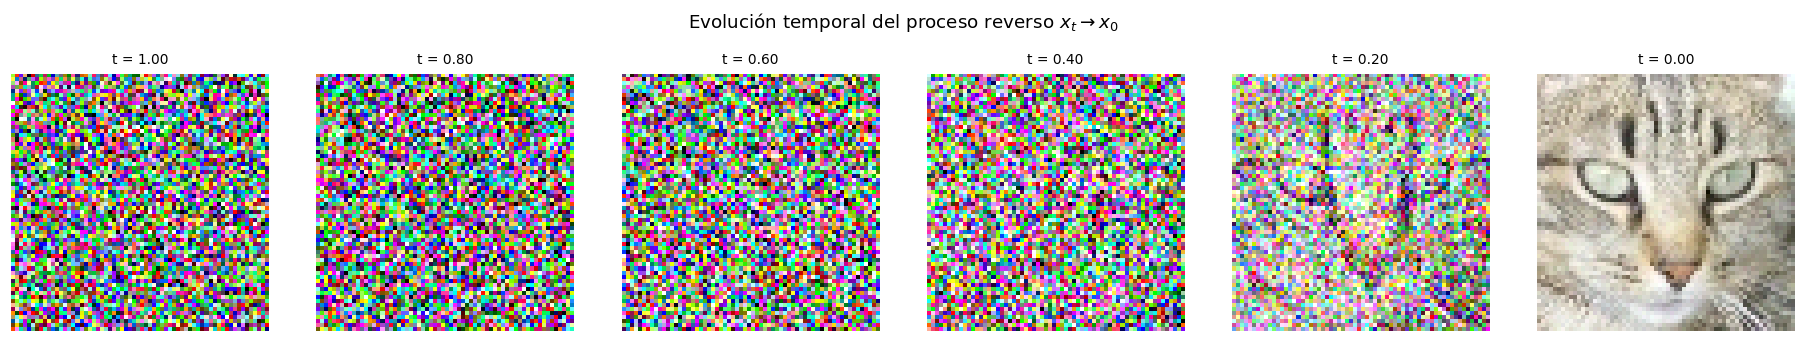

In [ ]:
# --- Captura y visualización de la trayectoria reverso (en GPU) ---
NFE_TRAJ = 1000                              # presupuesto en evaluaciones de la U-Net
N_STEPS_TRAJ = pasos_para("pc", NFE_TRAJ)    # 'pc' gasta 2 por paso -> 500 pasos
# (van al CONSTRUCTOR del sampler, NO a sample())

state_dict, meta = load_checkpoint(CKPT_PATH, map_location="cpu")
sde = make_sde(meta["sde_name"], data_dim=meta["data_dim"])
raw_net = make_model(meta["model"]["name"], **dict(meta["model"]["kwargs"]))

if meta["model"].get("score_parametrization") == "epsilon":
    net = EpsilonScoreWrapper(raw_net, lambda x, t: sde.marginal_prob(x, t)[1])
else:
    net = raw_net

net.load_state_dict(state_dict)
net.eval().to("cuda")                       # red a GPU

# n_steps va al CONSTRUCTOR del sampler (sample() no recibe n_steps):
sampler = make_sampler("pc", sde=sde, score_fn=net, n_steps=N_STEPS_TRAJ,
                       **kwargs_para("pc"))
print(f"pc: {N_STEPS_TRAJ} pasos x {NFE_POR_PASO['pc']} = {NFE_TRAJ} NFE")

g = torch.Generator(device="cuda").manual_seed(SEED)                       # generator en cuda
x_T = sde.prior_sampling(shape=(1, *sde.data_shape), generator=g, device="cuda")

# n_samples=1 (coincide con el batch de init), NO N_STEPS_TRAJ:
x_0, trajectory = sampler.sample(n_samples=1, init=x_T, return_trajectory=True, generator=g)

print(f"Trayectoria capturada: shape={tuple(trajectory.shape)}")  # (N_STEPS_TRAJ+1, 1, 3, H, W)

indices = np.linspace(0, len(trajectory) - 1, 6, dtype=int)
traj_samples = trajectory[indices, 0]       # (6, 3, H, W); denorm hace .cpu()

t_values = np.linspace(sde.T, 1e-4, len(trajectory))[indices]
titles = [f"t = {t:.2f}" for t in t_values]

show_grid(
    traj_samples,
    titles=titles,
    suptitle=r"Evolución temporal del proceso reverso $x_t \to x_0$",
    cols=6
)

## 5. Análisis de Overfitting: Búsqueda de Vecinos Más Cercanos en el Dataset

Para determinar si el modelo **memorizó** especímenes concretos del entrenamiento (overfitting) o si **aprendió la distribución subyacente** (generalización):
- Cargamos un conjunto de imágenes reales del dataset de entrenamiento.
- Calculamos la distancia Mean Squared Error (MSE) en espacio de píxeles entre cada muestra generada $x_{\text{gen}}$ y todas las imágenes del dataset $x_{\text{real}}$.
- Mostramos para cada muestra generada sus $K$ **vecinos más cercanos (Nearest Neighbors)** junto con su distancia MSE.

> **Interpretación:**
> - **Si MSE $\approx 0$ e imagen idéntica:** El modelo memorizó esa imagen exacta del entrenamiento.
> - **Si MSE $> 0$ y difiere en rasgos:** El modelo generalizó y produjo una nueva instancia que comparte características de la variedad de gatos pero no copia a ningún gato del dataset.

Cargando dataset desde: /home/abravo/estocastico/diffusion-models/data/cats-v1


Comparando contra 18608 imágenes (9304 originales + 9304 espejadas), 64x64


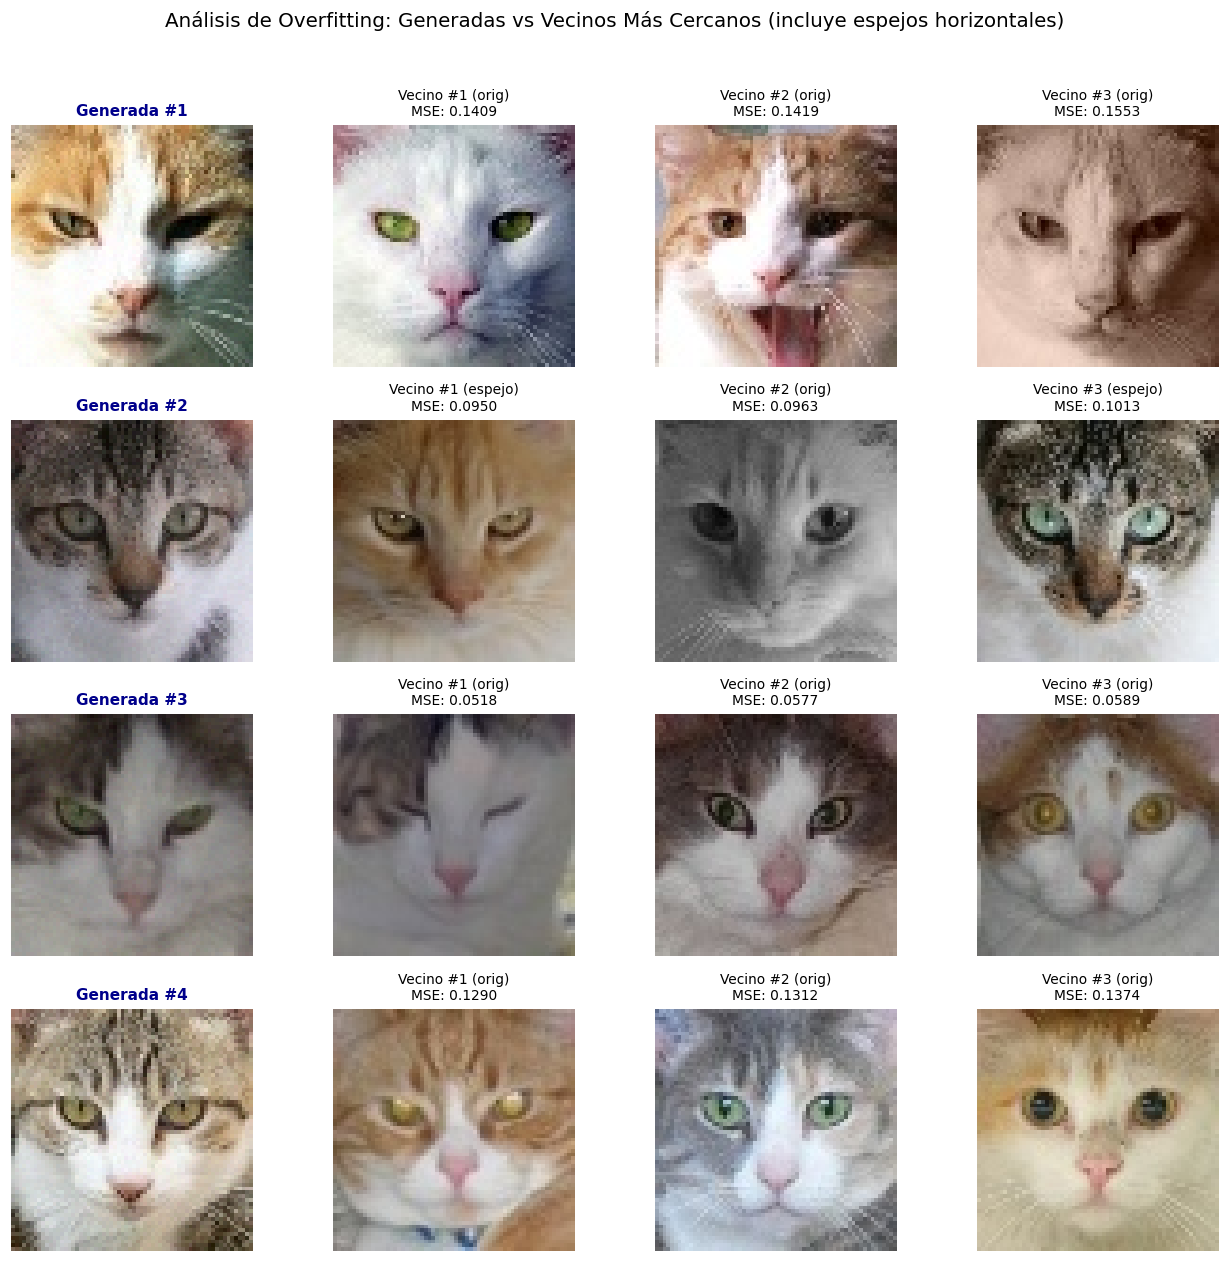

In [22]:
# --- 5. Búsqueda de vecinos más cercanos en el dataset (incluye espejos horizontales) ---
# Para detectar memorización comparamos cada muestra generada contra CADA gato del dataset en
# AMBAS orientaciones (original + espejo horizontal). El entrenamiento usa flip horizontal, así que
# un gato "memorizado pero dado vuelta" solo aparece si consideramos también el espejo.
data_dir_candidates = [
    _root / "data" / "cats-v1",
]

DATA_DIR = None
for d_cand in data_dir_candidates:
    if d_cand.exists() and any(d_cand.iterdir()):
        DATA_DIR = d_cand
        break

if DATA_DIR is None:
    print("No se encontró carpeta de dataset de imágenes en data/. Salteando la búsqueda de vecinos.")
else:
    print(f"Cargando dataset desde: {DATA_DIR}")
    img_size = meta["model"]["kwargs"].get("image_size", sde.data_shape[-1])

    # batch_size no puede superar la cantidad de imágenes (infinite_batches hace fail-fast):
    _exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    n_imgs = sum(1 for p in DATA_DIR.rglob("*") if p.suffix.lower() in _exts)

    # augment=False -> orientación canónica y determinística; el espejo lo agregamos a mano.
    dataset_iter = infinite_batches(
        DATA_DIR, batch_size=n_imgs, image_size=img_size,
        augment=False, shuffle=False, num_workers=0, seed=SEED
    )
    X_dataset = next(dataset_iter)                    # (N, 3, H, W) en CPU
    X_flip = torch.flip(X_dataset, dims=[-1])         # espejo horizontal (última dim = ancho)
    X_all = torch.cat([X_dataset, X_flip], dim=0)     # (2N, 3, H, W): [originales | espejadas]
    N = X_dataset.shape[0]
    print(f"Comparando contra {X_all.shape[0]} imágenes ({N} originales + {N} espejadas), {img_size}x{img_size}")

    # Búsqueda de Top-K vecinos para las muestras generadas en la Sección 2.
    samples_cpu = samples_pc.cpu()  # asegurar CPU (X_all está en CPU)
    N_gen = samples_cpu.shape[0]
    K_NEIGHBORS = 3

    fig, axes = plt.subplots(
        N_gen, K_NEIGHBORS + 1,
        figsize=(3.0 * (K_NEIGHBORS + 1), 2.8 * N_gen)
    )
    if N_gen == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(N_gen):
        gen_img = samples_cpu[i:i+1]  # (1, 3, H, W) en CPU
        # Distancia MSE en píxeles contra originales Y espejos: promediar sobre (C, H, W)
        mse_distances = torch.mean((X_all - gen_img) ** 2, dim=(1, 2, 3)).cpu().numpy()  # (2N,)

        # Índices con menor MSE (sobre el set duplicado original+espejo)
        top_k_indices = np.argsort(mse_distances)[:K_NEIGHBORS]

        # Columna 0: Imagen generada
        axes[i, 0].imshow(denorm(gen_img)[0])
        axes[i, 0].set_title(f"Generada #{i+1}", fontsize=10, fontweight="bold", color="darkblue")
        axes[i, 0].axis("off")

        # Columnas 1..K: Vecinos más cercanos (con etiqueta de orientación)
        for k_idx, neighbor_idx in enumerate(top_k_indices):
            etiqueta = "espejo" if neighbor_idx >= N else "orig"   # idx >= N -> vino de X_flip
            neighbor_img = X_all[neighbor_idx:neighbor_idx + 1]
            dist = mse_distances[neighbor_idx]

            axes[i, k_idx + 1].imshow(denorm(neighbor_img)[0])
            axes[i, k_idx + 1].set_title(f"Vecino #{k_idx+1} ({etiqueta})\nMSE: {dist:.4f}", fontsize=9)
            axes[i, k_idx + 1].axis("off")

    fig.suptitle("Análisis de Overfitting: Generadas vs Vecinos Más Cercanos (incluye espejos horizontales)", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

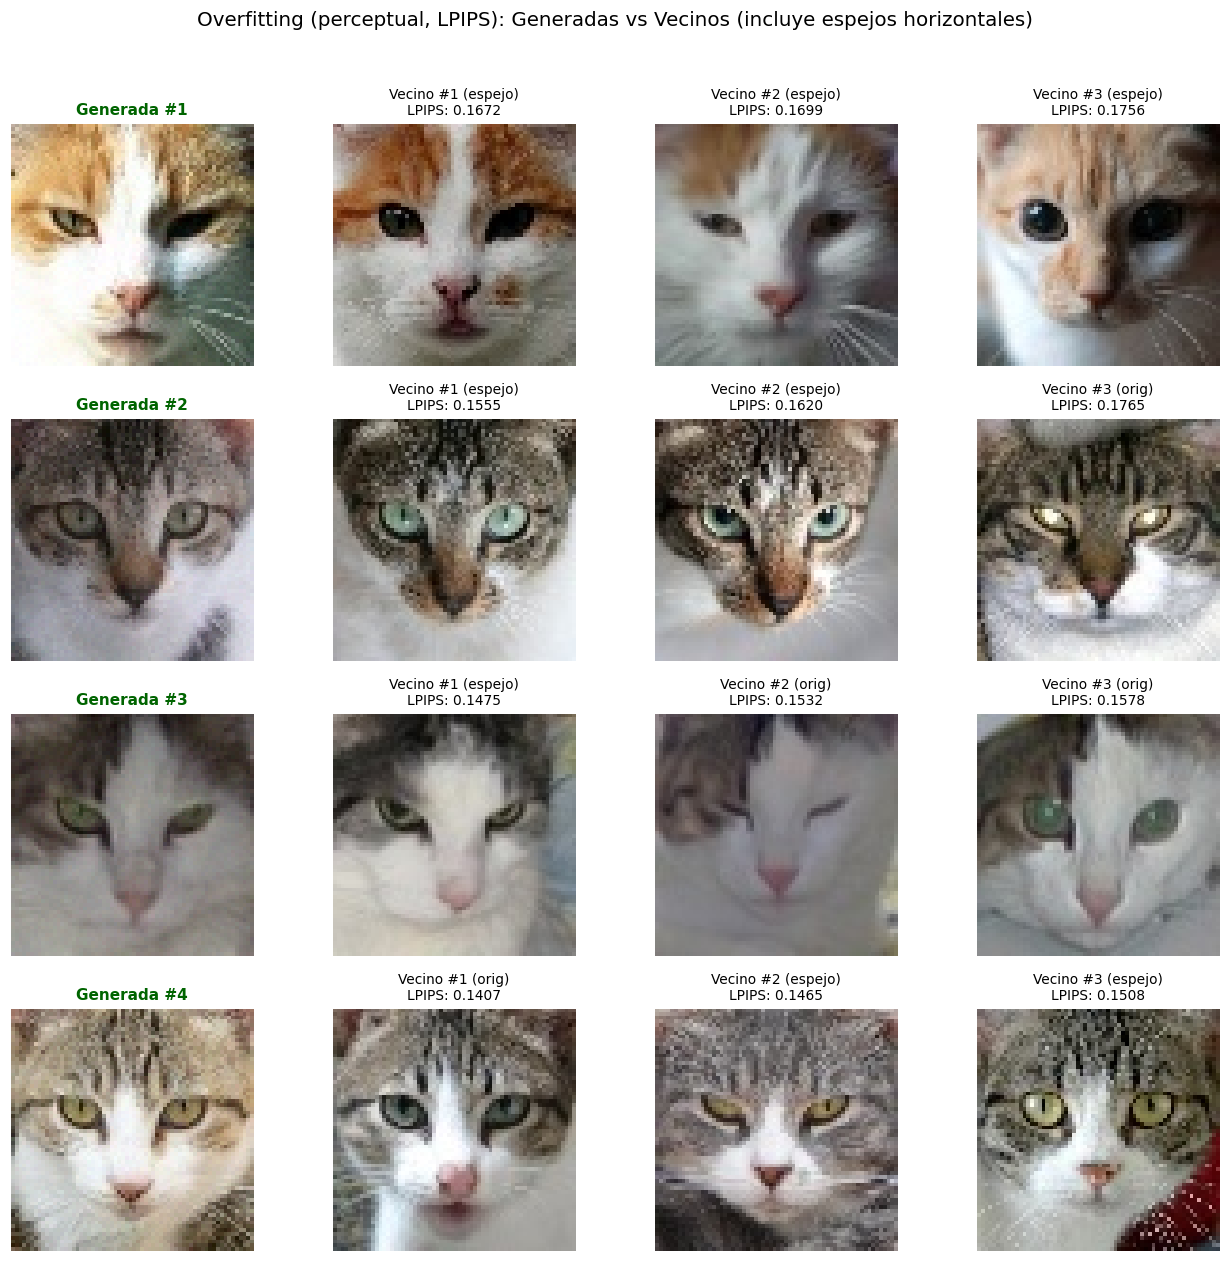

In [23]:
# --- 5b. Vecinos más cercanos en espacio PERCEPTUAL (LPIPS) ---
# MSE (celda anterior) detecta copias casi-exactas pero es sensible a corrimientos/color y se deja
# engañar por el fondo. LPIPS mide parecido PERCEPTUAL (distancia en features de una red preentrenada),
# robusto a esos corrimientos -> mejor para "¿a qué gato se parece de verdad?".
# Requiere el paquete `lpips`:  uv add lpips   (descarga pesos AlexNet la 1ra vez -> necesita internet).
# Reutiliza X_all (originales + espejos), samples_cpu, N_gen y denorm de la celda anterior.
try:
    import lpips
    _HAS_LPIPS = True
except ImportError:
    _HAS_LPIPS = False
    print("Falta el paquete 'lpips'. Instalalo con `uv add lpips` (o `pip install lpips`) y re-corré esta celda.")

if _HAS_LPIPS and DATA_DIR is not None:
    lpips_device = "cuda" if torch.cuda.is_available() else "cpu"
    lpips_fn = lpips.LPIPS(net="alex", verbose=False).to(lpips_device).eval()

    # LPIPS espera RGB en [-1, 1] (B,3,H,W) -> es EXACTAMENTE el rango de X_all y de las muestras,
    # así que NO se des-normaliza para la métrica (denorm es solo para mostrar).
    X_all_dev = X_all.to(lpips_device)
    N = X_dataset.shape[0]
    K_NEIGHBORS = 3
    CHUNK = 256  # procesar X_all de a bloques para no reventar la memoria

    fig, axes = plt.subplots(
        N_gen, K_NEIGHBORS + 1,
        figsize=(3.0 * (K_NEIGHBORS + 1), 2.8 * N_gen)
    )
    if N_gen == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for i in range(N_gen):
            gen = samples_cpu[i:i+1].to(lpips_device)          # (1,3,H,W) en [-1,1]
            dists = []
            for s in range(0, X_all_dev.shape[0], CHUNK):
                block = X_all_dev[s:s+CHUNK]
                gen_rep = gen.repeat(block.shape[0], 1, 1, 1)  # (b,3,H,W)
                d = lpips_fn(gen_rep, block)                   # (b,1,1,1)
                dists.append(d.flatten().cpu())
            lpips_d = torch.cat(dists).numpy()                 # (2N,)
            top_k = np.argsort(lpips_d)[:K_NEIGHBORS]

            axes[i, 0].imshow(denorm(samples_cpu[i:i+1])[0])
            axes[i, 0].set_title(f"Generada #{i+1}", fontsize=10, fontweight="bold", color="darkgreen")
            axes[i, 0].axis("off")

            for k_idx, idx in enumerate(top_k):
                etiqueta = "espejo" if idx >= N else "orig"    # idx >= N -> vino de X_flip
                axes[i, k_idx + 1].imshow(denorm(X_all[idx:idx+1])[0])
                axes[i, k_idx + 1].set_title(f"Vecino #{k_idx+1} ({etiqueta})\nLPIPS: {lpips_d[idx]:.4f}", fontsize=9)
                axes[i, k_idx + 1].axis("off")

    fig.suptitle("Overfitting (perceptual, LPIPS): Generadas vs Vecinos (incluye espejos horizontales)", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

## Cierre y Resumen

- **Carga de Checkpoint**: El notebook se integra con las salidas producidas por `config/cats_vp.yaml` (`ScoreUNet` + `VP-SDE`).
- **Generación desde ruido**: Se utilizó `generate_from_checkpoint` para reconstruir imágenes a partir de prior gaussiano $x_T \sim \mathcal{N}(0, I)$.
- **Estudio de Ablación (Eje 2)**: Se compararon los samplers `euler`, `pf_ode`, `heun` y `pc` bajo la misma semilla, comprobando que cambiar la estrategia de muestreo no requiere modificar ni reentrenar la red de score.
- **Análisis de Overfitting / Generalización**: La búsqueda de vecinos más cercanos (Nearest Neighbors) permite constatar empíricamente el nivel de memorización vs aprendizaje de la variedad subyacente.